Импорт необходимых библиотек

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier


Размерность данных и первые 5 строк

In [33]:
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
print(df.head())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

Общая информация о данных

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

Проверка пропусков

In [35]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Целевая переменная

In [36]:
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True).round(2))

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.84
Yes    0.16
Name: proportion, dtype: float64


Визуализация дисбаланса

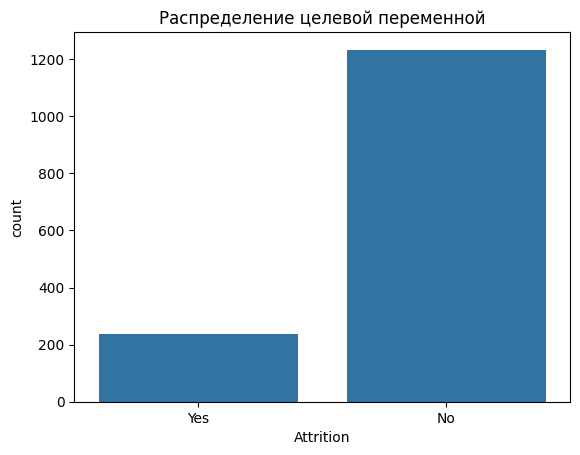

In [37]:
sns.countplot(x='Attrition', data=df)
plt.title('Распределение целевой переменной')
plt.show()

Удаляем бесполезные колонки

In [38]:
# Эти колонки одинаковые у всех сотрудников — никакой информации не несут
print(df['EmployeeCount'].unique())
print(df['Over18'].unique())
print(df['StandardHours'].unique())

# EmployeeNumber - это просто ID, смысла не несёт, тоже удаляем
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

# проверяем текущую размерность
print(df.shape)  # должно быть (1470, 31)

[1]
<ArrowStringArray>
['Y']
Length: 1, dtype: str
[80]
(1470, 31)


Сводка по числовым столбцам

In [39]:
df.describe().round(1)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,...,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,36.9,802.5,9.2,2.9,2.7,65.9,2.7,2.1,2.7,6502.9,...,3.2,2.7,0.8,11.3,2.8,2.8,7.0,4.2,2.2,4.1
std,9.1,403.5,8.1,1.0,1.1,20.3,0.7,1.1,1.1,4708.0,...,0.4,1.1,0.9,7.8,1.3,0.7,6.1,3.6,3.2,3.6
min,18.0,102.0,1.0,1.0,1.0,30.0,1.0,1.0,1.0,1009.0,...,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,30.0,465.0,2.0,2.0,2.0,48.0,2.0,1.0,2.0,2911.0,...,3.0,2.0,0.0,6.0,2.0,2.0,3.0,2.0,0.0,2.0
50%,36.0,802.0,7.0,3.0,3.0,66.0,3.0,2.0,3.0,4919.0,...,3.0,3.0,1.0,10.0,3.0,3.0,5.0,3.0,1.0,3.0
75%,43.0,1157.0,14.0,4.0,4.0,83.8,3.0,3.0,4.0,8379.0,...,3.0,4.0,1.0,15.0,3.0,3.0,9.0,7.0,3.0,7.0
max,60.0,1499.0,29.0,5.0,4.0,100.0,4.0,5.0,4.0,19999.0,...,4.0,4.0,3.0,40.0,6.0,4.0,40.0,18.0,15.0,17.0


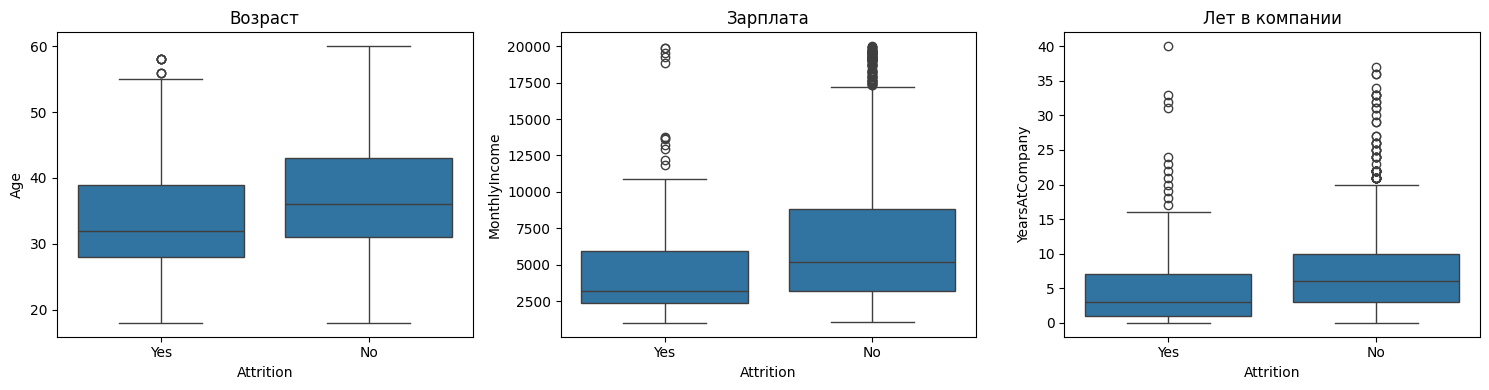

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x='Attrition', y='Age', data=df, ax=axes[0])
axes[0].set_title('Возраст')

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[1])
axes[1].set_title('Зарплата')

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[2])
axes[2].set_title('Лет в компании')

plt.tight_layout()
plt.show()

Анализ распределения признаков по факту увольнения (Attrition):

1. MonthlyIncome   - критичен: медиана уволившихся на 40% ниже
2. YearsAtCompany  - важен: увольняются преимущественно новички  
3. Age            - не влияет: распределения идентичны

**Люди с низким доходом, новенькие в компании, увольняются чаще.**

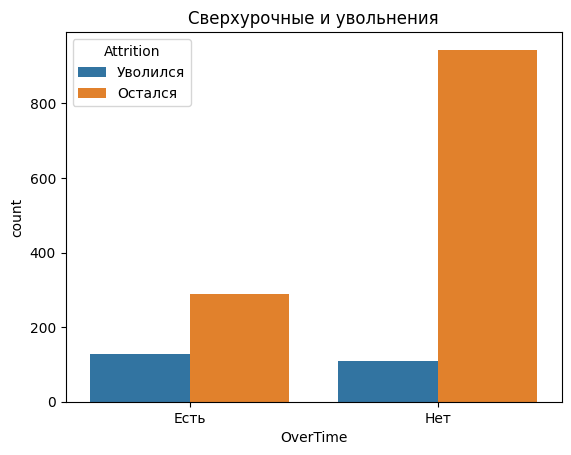

In [41]:
# Переименуем значения для ясности
df_renamed = df.copy()
df_renamed['Attrition'] = df_renamed['Attrition'].map({'Yes': 'Уволился', 'No': 'Остался'})
df_renamed['OverTime'] = df_renamed['OverTime'].map({'Yes': 'Есть', 'No': 'Нет'})

sns.countplot(x='OverTime', hue='Attrition', data=df_renamed)
plt.title('Сверхурочные и увольнения')
plt.show()

Сверхурочная работа сильно коррелирует с увольнениями:
- Без переработок: ~85% остаются
- С переработками: ~40% увольняются

**Те, кто работают сверхурочно, уходят чаще.**

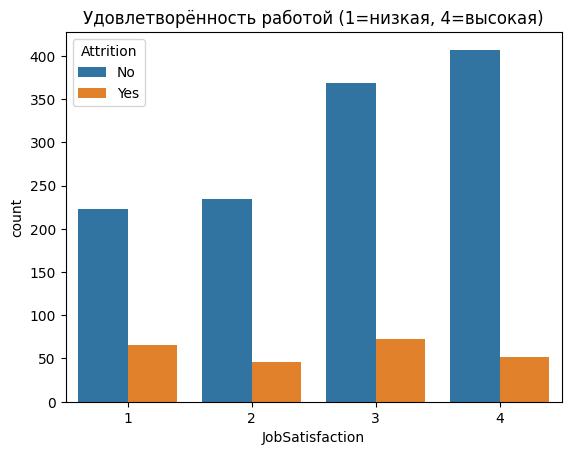

In [42]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title('Удовлетворённость работой (1=низкая, 4=высокая)')
plt.show()

- Чем НИЖЕ удовлетворенность работой (1-2), тем ВЫШЕ доля уволившихся
- Чем ВЫШЕ удовлетворенность (3-4), тем НИЖЕ доля уволившихся

**Удовлетворенность работой - важный предиктор оттока сотрудников.**

In [43]:
# Сначала переведём Attrition в 0/1 для корреляции
df['Attrition_num'] = (df['Attrition'] == 'Yes').astype(int)

# Считаем корреляции с целевой переменной
correlations = df.select_dtypes(include='number').corr()['Attrition_num'].sort_values()
print(correlations)

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
Attrition_num               1.000000
Name: Attrition_num, dtype: float64


## Выводы по EDA

- **Дисбаланс классов:** 84% остались, 16% уволились — модель нужно обучать с учётом этого
- **Ключевые факторы увольнения:**
  - низкая зарплата (`MonthlyIncome`)
  - сверхурочная работа (`OverTime`)
  - удалённость от работы (`DistanceFromHome`)
  - частая смена работ (`NumCompaniesWorked`)

## Подготовка данных

- Текстовые признаки закодированы числами через `LabelEncoder`
- Итоговый датасет: 1470 строк, 31 колонка, все значения числовые
- Целевая переменная: `Attrition` (0 = остался, 1 = уволился)

In [44]:
# Посмотрим, какие колонки текстовые
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(cat_cols)

# Кодируем все текстовые колонки в числа
le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col]) # type: ignore

df_encoded.head()

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_num
0,41,1,2,1102,2,1,2,1,2,0,...,1,0,8,0,1,6,4,0,5,1
1,49,0,1,279,1,8,1,1,3,1,...,4,1,10,3,3,10,7,1,7,0
2,37,1,2,1373,1,2,2,4,4,1,...,2,0,7,3,3,0,0,0,0,1
3,33,0,1,1392,1,3,4,1,4,0,...,3,0,8,3,3,8,7,3,0,0
4,27,0,2,591,1,2,1,3,1,1,...,4,1,6,3,3,2,2,2,2,0


Разбивка на train/test

In [45]:
X = df_encoded.drop(columns=['Attrition', 'Attrition_num'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% на тест
    random_state=42,      # фиксируем случайность — результат всегда одинаковый
    stratify=y            # сохраняем пропорцию 84/16 в обеих частях
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1176, 30), Test: (294, 30)


## Модели

Будем обучать три модели и сравнивать их:
1. Логистическая регрессия — простейший baseline
2. Decision Tree — дерево решений
3. Random Forest — ансамбль деревьев (ожидаем лучший результат)

Основная метрика: **ROC-AUC** — показывает, насколько хорошо модель 
различает два класса независимо от дисбаланса.
Дополнительно смотрим на **Recall** — насколько хорошо ловим тех, кто уйдёт.

In [46]:
# Вспомогательная функция для оценки
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    
    print(f'=== {model_name} ===')
    print(f'ROC-AUC: {auc:.3f}')
    print(classification_report(y_test, y_pred, target_names=['Остался', 'Уволился']))
    
    return auc

#### Логистическая регрессия

In [47]:
lr = Pipeline([
    ('scaler', StandardScaler()), # нормализация признаков
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr.fit(X_train, y_train)
auc_lr = evaluate_model(lr, X_test, y_test, 'Логистическая регрессия')

=== Логистическая регрессия ===
ROC-AUC: 0.807
              precision    recall  f1-score   support

     Остался       0.94      0.75      0.84       247
    Уволился       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



#### Decision Tree

In [48]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)
auc_dt = evaluate_model(dt, X_test, y_test, 'Decision Tree')

=== Decision Tree ===
ROC-AUC: 0.572
              precision    recall  f1-score   support

     Остался       0.86      0.85      0.85       247
    Уволился       0.27      0.30      0.28        47

    accuracy                           0.76       294
   macro avg       0.57      0.57      0.57       294
weighted avg       0.77      0.76      0.76       294



#### Random Forest

In [49]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'n_estimators': [50, 100, 200],
    'min_samples_leaf': [1, 5, 10]
}

rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,               # 5-fold кросс-валидация
    scoring='roc_auc',  # оптимизируем именно ROC-AUC
    n_jobs=-1           # используем все ядра процессора
)

rf.fit(X_train, y_train)
print(f'Лучшие параметры: {rf.best_params_}')
auc_rf = evaluate_model(rf.best_estimator_, X_test, y_test, 'Random Forest')

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
=== Random Forest ===
ROC-AUC: 0.786
              precision    recall  f1-score   support

     Остался       0.85      0.98      0.91       247
    Уволился       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



### LightGBM

In [50]:
lgbm = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    verbose=-1          # отключаем информационные сообщения
)

lgbm.fit(X_train, y_train)
auc_lgbm = evaluate_model(lgbm, X_test, y_test, 'LightGBM')

=== LightGBM ===
ROC-AUC: 0.787
              precision    recall  f1-score   support

     Остался       0.89      0.92      0.90       247
    Уволился       0.47      0.38      0.42        47

    accuracy                           0.83       294
   macro avg       0.68      0.65      0.66       294
weighted avg       0.82      0.83      0.83       294



## Итоговое сравнение моделей

In [51]:
results = {
    'Логистическая регрессия': (auc_lr, lr),
    'Decision Tree': (auc_dt, dt),
    'Random Forest': (auc_rf, rf.best_estimator_),
    'LightGBM': (auc_lgbm, lgbm),
}

print(f"{'Модель':<30} {'ROC-AUC':>9} {'Recall (уволился)':>20}")
print('-' * 60)
for name, (auc, model) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred, pos_label=1)
    print(f"{name:<30} {auc:>8.3f} {recall:>18.2f}")

Модель                           ROC-AUC    Recall (уволился)
------------------------------------------------------------
Логистическая регрессия           0.807               0.77
LightGBM                          0.787               0.38
Random Forest                     0.786               0.09
Decision Tree                     0.572               0.30


## Финальная модель: Логистическая регрессия

Логрегрессия выиграла по обеим ключевым метрикам:
- Лучший ROC-AUC (0.807)
- Лучший Recall (0.77) — находит 77% сотрудников в зоне риска

LightGBM и Random Forest переобучаются на маленьком датасете (1470 строк).
Для HR-задачи важнее не пропустить сотрудника который уйдёт (recall),
чем дать ложную тревогу — поэтому recall является приоритетной метрикой
наряду с ROC-AUC.

Сохраняем обученную модель в файл, чтобы API мог её загрузить и использовать

In [52]:
joblib.dump(lr, '../artifacts/model.pkl')
model = joblib.load('../artifacts/model.pkl')
test_pred = model.predict_proba(X_test[:3])[:, 1]
print('Вероятности для первых 3 сотрудников:', test_pred.round(3))


Вероятности для первых 3 сотрудников: [0.475 0.056 0.56 ]
